# Phase 1 optimizer -- launch mesh grading near hand-off

This is one of 7 notebooks in `notebooks/phase1_optimization/`.
Equation/section citations here follow `docs/tt pacing optimizer.md`, the
project's canonical numbering, written as "(design-doc Eq. N)" /
"(design-doc Section N.M)"; display-unit conventions (km/min/km-h⁻¹) are
implemented in `phase_1_0_common.py`'s `as_km`/`as_min`/`as_kmh` helpers, shared
by all 7 notebooks. This one covers
**why the collocation mesh needs grading (not uniform spacing) near the standing-start launch hand-off, including a deliberately reconstructed failure case**.

It is fully self-contained: every rider/course/baseline it needs is
rebuilt here via `phase_1_0_common.py` (shared by all 7 split notebooks),
so it runs standalone from a fresh kernel without any other notebook
having run first. Courses used: synthetic flat + Giro10, TdF16 (real). Approx. runtime: ~1.1 min (measured).

In [1]:
import sys
sys.path.insert(0, ".")
import phase_1_0_common as pc

pc.print_rider_summary()

from ttt_strat.collocation import CollocationProblem
from ttt_strat.optimizer import SLSQPSolver, _equilibrium_speed_and_relax_length, _graded_mesh
from ttt_strat.simulator import ForwardSimulator, _launch_and_truncate
import numpy as np
import matplotlib.pyplot as plt

reference_rider        mass= 72.0 kg  CP= 280.0 W  W'= 20.0 kJ  CdA=0.25 m^2  P_max=   900 W
evenepoel_like_rider   mass= 63.5 kg  CP= 425.0 W  W'= 20.0 kJ  CdA=0.21 m^2  P_max=  1400 W
ganna_like_rider       mass= 82.0 kg  CP= 480.0 W  W'= 20.0 kJ  CdA=0.19 m^2  P_max=  1600 W


## Mesh grading near launch hand-off (design-doc Section 10.6 / Section 8)

### 3.1 Why the mesh needs grading at all

The standing-start launch (time-domain integration from rest up to a
hand-off speed `v_match_m_per_s`) is computed separately and feeds the
collocation problem its boundary condition; `CollocationProblem` itself
always operates on the **post-launch** distance sub-grid, starting at the
hand-off point $s_{match}$. Immediately after hand-off, speed relaxes from
$v_{match}$ toward a local equilibrium speed over a length scale

$$
L = \left. \left| \frac{d}{dv}\left(\frac{dv}{ds}\right) \right|^{-1} \right|_{v = v_{eq}}
$$

- $L$ -- acceleration relaxation length [m]
- $v_{eq}$ -- local equilibrium speed (where $dv/ds = 0$) [m/s]

$L$ varies roughly 10x across realistic rider/course combinations (about
20 m on a steep climb to about 225 m for a strong rider on a fast flat
course), so `ITTOptimizer` grades the first several collocation intervals
as growing fractions of $L$ (`_equilibrium_speed_and_relax_length` +
`_graded_mesh`) rather than using a fixed schedule; $L$ is a linearization
derived from Eq. 9 (design-doc), not itself a separately numbered
equation. (This subsection uses
metres, not km, throughout -- these are metre-to-hundred-metre-scale
quantities near a single hand-off point, not course-scale distances.)

The ramp stops as soon as a step would exceed the width of the uniform
intervals that follow it, so how many intervals get graded is derived from
`n_intervals` rather than fixed. Letting it keep doubling to $8L$ put a
single interval of up to 1.9 km in the middle of real terrain a few
hundred metres into the course -- the same under-resolution this notebook
reconstructs below, reintroduced by the cure -- and because that block was
also capped at 9 intervals regardless of `n_intervals`, refining the mesh
never reached it and the resulting terrain error stayed frozen (issue #6,
item 7.1). `tests/test_phase_1.py::test_graded_mesh_represents_the_course`
is the gate on that; this notebook's concern is the launch transient the
fine end of the ramp exists to resolve, which the cap leaves untouched at
$L/32$.

### 3.2 Working baseline: synthetic course plus two real courses

A synthetic flat-course Hermite-Simpson/SLSQP baseline (`res_hs_flat`) is
built below as a controlled baseline -- no real-terrain noise to
entangle with the mesh-grading effect itself. Two real GPX courses are
added, chosen to be as different in terrain as possible:

- **Giro 2026 Stage 10** (flat): about 40 km with well under 100 m of total
  elevation range and a mean |grade| under 1%.
- **TdF 2026 Stage 16** (mountainous/uphill): about 26 km with several
  hundred metres of elevation range and a mean |grade| well over ten times
  Giro10's, with sustained sections above 5%.
  (`docs/plans/phase-1.md` independently and repeatedly flags this stage
  as the difficult climbing case during development.) Exact figures are
  computed live in the next cell. Note these are gentler than the figures
  this notebook used to report: at the 300 m smoothing length used here,
  correcting the course processing (issue #5) removed the double-digit
  grade spikes that were artifacts of differentiating raw GPS elevation
  before resampling it.

TARA Stage 3 (the third real course from the commit) is intermediate/
rolling terrain by the same measures; it is used in the real-course
validation notebook instead, where all three real courses appear
together.

In [2]:
def summarize_terrain(course) -> None:
    """Print distance, elevation range, and grade statistics for a ProcessedCourse."""
    grade = np.tan(course.theta_rad)
    elev_m = np.concatenate([[0.0], np.cumsum(grade[:-1] * np.diff(course.s_m))])
    print(
        f"  distance={pc.as_km(course.s_m[-1]):6.2f} km  "
        f"elev_range={elev_m.max() - elev_m.min():6.1f} m  "
        f"mean|grade|={np.mean(np.abs(grade)) * 100:5.2f}%  "
        f"grade=[{grade.min() * 100:5.1f}%, {grade.max() * 100:5.1f}%]"
    )


flat_course = pc.build_flat_course()
opt_hs_flat, res_hs_flat = pc.build_hs_baseline(pc.reference_rider, flat_course, pc.calm_wind, pc.N_INTERVALS_BASIC)

giro10_data = pc.load_gpx(pc.GPX_DIR / "giro2026_stage10.gpx")
giro10_course = pc.CourseProcessor().process(
    giro10_data, n_nodes=len(giro10_data.s_m), smoothing_length_m=300.0
)
tdf16_data = pc.load_gpx(pc.GPX_DIR / "tdf2026_stage16.gpx")
tdf16_course = pc.CourseProcessor().process(
    tdf16_data, n_nodes=min(len(tdf16_data.s_m), 800), smoothing_length_m=300.0
)

print("Giro 2026 Stage 10 (flat):")
summarize_terrain(giro10_course)
print("TdF 2026 Stage 16 (mountainous/uphill):")
summarize_terrain(tdf16_course)
print("Synthetic flat course:")
summarize_terrain(flat_course)

Giro 2026 Stage 10 (flat):
  distance= 40.04 km  elev_range=  18.1 m  mean|grade|= 0.23%  grade=[ -1.4%,   1.7%]
TdF 2026 Stage 16 (mountainous/uphill):
  distance= 26.03 km  elev_range= 429.6 m  mean|grade|= 3.42%  grade=[ -8.3%,   5.8%]
Synthetic flat course:
  distance= 40.00 km  elev_range=  40.0 m  mean|grade|= 0.10%  grade=[  0.1%,   0.1%]


In [3]:
opt_giro10 = pc.ITTOptimizer(
    pc.ganna_like_rider, giro10_course, pc.calm_wind, scheme="hermite_simpson", solver="slsqp"
)
res_giro10_baseline = opt_giro10.optimize(n_intervals=80)

opt_tdf16 = pc.ITTOptimizer(
    pc.evenepoel_like_rider, tdf16_course, pc.calm_wind, scheme="hermite_simpson", solver="slsqp"
)
res_tdf16_baseline = opt_tdf16.optimize(n_intervals=60)

for label, res in [
    ("Synthetic flat", res_hs_flat),
    ("Giro10 (flat)", res_giro10_baseline),
    ("TdF16 (mountainous)", res_tdf16_baseline),
]:
    print(f"{label:22s} T = {pc.as_min(res.time_total_s):7.2f} min   launch burst peak power = "
          f"{res.power_W[:9].max():6.1f} W")

Synthetic flat         T =   57.12 min   launch burst peak power =  900.0 W
Giro10 (flat)          T =   43.29 min   launch burst peak power = 1600.0 W
TdF16 (mountainous)    T =   32.28 min   launch burst peak power = 1400.0 W


### 3.3 Failure case: what an under-resolved launch interval does

No test in `tests/test_phase_1*.py` exercises this failure mode directly
-- it is reconstructed here from the production functions themselves, as
an illustration only (flagged again in the cross-check ledger notebook).

`_graded_mesh`'s own docstring documents the mechanism: a **uniform**
mesh spanning the launch relaxation region packs the entire
$v_{match} \to v_{eq}$ transient into a single Hermite-Simpson interval.
Because a single cubic cannot represent that transient, the solver can
satisfy the discretized Hermite-Simpson defect equations (design-doc Eq. 42)
with a trajectory that is not a real solution of the `dv/ds` ODE (design-doc
Eq. 9) -- the defect equations only constrain
the endpoints and one interpolated midpoint, so a large enough interval
leaves room for a spurious, unphysical spike between them that still
zeroes out the (under-determined) defect residual.

The comparison below changes exactly one thing relative to the 3.2
synthetic-flat-course baseline (`res_hs_flat`): whether the first few
intervals are graded near the hand-off (`_graded_mesh`, the production
default) or left uniform (`np.linspace`) -- same rider, same course, same
solver, same `n_intervals`.

In [4]:
v_w_flat = pc.calm_wind.head_wind_m_per_s(flat_course.bearing_rad)
t_match_s, s_match_m, w_after_launch_J, i_start = _launch_and_truncate(
    pc.reference_rider, flat_course, v_w_flat, 1.225, opt_hs_flat.v_match_m_per_s
)
s_sub = flat_course.s_m[i_start:]
theta_sub = flat_course.theta_rad[i_start:]
vw_sub = v_w_flat[i_start:]

v_eq_m_per_s, l_relax_m = _equilibrium_speed_and_relax_length(
    pc.reference_rider, float(theta_sub[0]), float(vw_sub[0]), 1.225, pc.reference_rider.cp_W
)
print(f"v_eq = {v_eq_m_per_s:.3f} m/s   l_relax_m (L, derived from Eq. 9) = {l_relax_m:.1f} m")


def solve_on_mesh(s_new: np.ndarray) -> tuple[np.ndarray, float, float, bool]:
    """Solve the post-launch NLP on a given mesh and cross-check with ForwardSimulator.

    Returns (power_W, T_nlp, T_sim, success).
    """
    v_max_m_per_s = max(v_eq_m_per_s * 2.5, 15.0)
    theta_new = np.interp(s_new, s_sub, theta_sub)
    vw_new = np.interp(s_new, s_sub, vw_sub)
    problem = CollocationProblem(
        pc.reference_rider, s_new, theta_new, vw_new, 1.225,
        v0_m_per_s=opt_hs_flat.v_match_m_per_s, w0_J=w_after_launch_J,
        scheme="hermite_simpson", v_max_m_per_s=v_max_m_per_s,
    )
    v_guess, w_guess, p_guess = opt_hs_flat._warm_start(
        s_new, theta_new, vw_new, opt_hs_flat.v_match_m_per_s, w_after_launch_J
    )
    p_mid_guess = 0.5 * (p_guess[:-1] + p_guess[1:])
    z0 = problem.pack(v_guess, w_guess, p_guess, p_mid_guess)
    z_opt, success, _message = SLSQPSolver().solve(problem, z0)
    v_opt, w_opt, p_opt, p_mid_opt = problem.unpack(z_opt)
    t_nlp_s = t_match_s + problem.objective(z_opt)

    full_power_W = np.empty(len(flat_course.s_m))
    full_power_W[:i_start] = p_opt[0]
    s_ctrl = np.empty(2 * problem.n_intervals + 1)
    p_ctrl = np.empty(2 * problem.n_intervals + 1)
    s_ctrl[0::2], p_ctrl[0::2] = s_new, p_opt
    s_ctrl[1::2] = 0.5 * (s_new[:-1] + s_new[1:])
    p_ctrl[1::2] = p_mid_opt
    full_power_W[i_start:] = np.interp(flat_course.s_m[i_start:], s_ctrl, p_ctrl)

    sim = ForwardSimulator().simulate(pc.reference_rider, flat_course, pc.calm_wind, full_power_W)
    return p_opt, t_nlp_s, sim.time_total_s, success


s_graded = _graded_mesh(s_sub[0], s_sub[-1], pc.N_INTERVALS_BASIC, l_relax_m)
s_uniform = np.linspace(s_sub[0], s_sub[-1], pc.N_INTERVALS_BASIC + 1)
print(f"graded first interval width:  {s_graded[1] - s_graded[0]:6.2f} m")
print(f"uniform first interval width: {s_uniform[1] - s_uniform[0]:6.2f} m  (>> L = {l_relax_m:.0f} m)")

p_graded, t_nlp_graded, t_sim_graded, success_graded = solve_on_mesh(s_graded)
p_uniform, t_nlp_uniform, t_sim_uniform, success_uniform = solve_on_mesh(s_uniform)

rel_graded = abs(t_sim_graded - t_nlp_graded) / t_nlp_graded
rel_uniform = abs(t_sim_uniform - t_nlp_uniform) / t_nlp_uniform
print()
print(f"GRADED  mesh: T_nlp={pc.as_min(t_nlp_graded):.4f} min  T_sim={pc.as_min(t_sim_graded):.4f} min  "
      f"rel_diff={rel_graded:.5f}  success={success_graded}")
print(f"UNIFORM mesh: T_nlp={pc.as_min(t_nlp_uniform):.4f} min  T_sim={pc.as_min(t_sim_uniform):.4f} min  "
      f"rel_diff={rel_uniform:.5f}  success={success_uniform}")

v_eq = 11.577 m/s   l_relax_m (L, derived from Eq. 9) = 149.9 m
graded first interval width:    4.68 m
uniform first interval width: 665.00 m  (>> L = 150 m)



GRADED  mesh: T_nlp=57.1178 min  T_sim=57.1883 min  rel_diff=0.00123  success=True
UNIFORM mesh: T_nlp=57.0158 min  T_sim=58.6076 min  rel_diff=0.02792  success=True


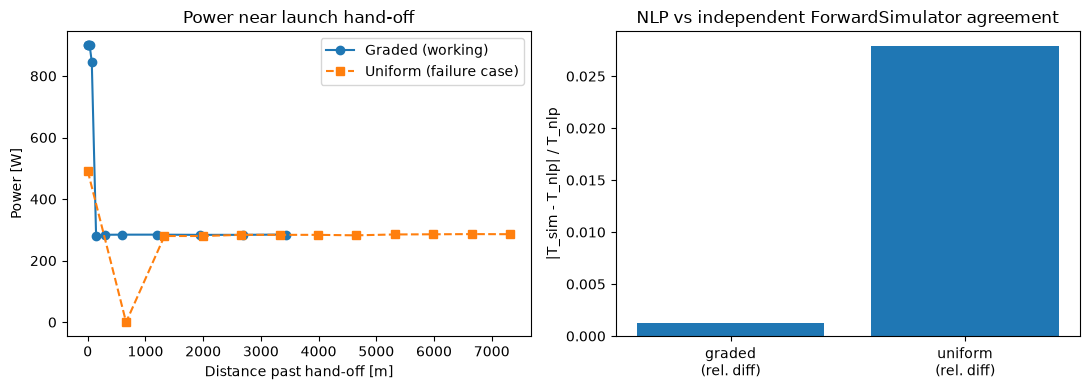

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
n_show = 12
axes[0].plot(s_graded[:n_show] - s_graded[0], p_graded[:n_show], "o-", label="Graded (working)")
axes[0].plot(s_uniform[:n_show] - s_uniform[0], p_uniform[:n_show], "s--", label="Uniform (failure case)")
axes[0].set_xlabel("Distance past hand-off [m]")
axes[0].set_ylabel("Power [W]")
axes[0].set_title("Power near launch hand-off")
axes[0].legend()

axes[1].bar(
    ["graded\n(rel. diff)", "uniform\n(rel. diff)"],
    [rel_graded, rel_uniform],
)
axes[1].set_ylabel("|T_sim - T_nlp| / T_nlp")
axes[1].set_title("NLP vs independent ForwardSimulator agreement")

fig.tight_layout()
plt.show()

The under-resolved (uniform) mesh's NLP-vs-independent-simulation
disagreement, 2.79%, is more than 20x the 0.12% the properly graded mesh
achieves -- the solver is satisfying the discretized equations at a
trajectory the independent forward simulator does not reproduce, exactly
the pathology the commit describes.

**Both meshes report `success=True`**, which is the sharpest available
demonstration that the solver's own flag is not the discriminator: one of
these two solves is pathological and the flag says nothing about which.
(Before issue #6 item 7.6 both reported `False` instead, for a reason that
had nothing to do with the mesh: SLSQP's `ftol` was unreachable, so every
solve exited on the iteration limit. Now that the flag means something, it
still does not mean *this*.) The graded-vs-uniform re-simulation gap is
what actually distinguishes a trustworthy solve from a pathological one.